# COVID-19 Dataset: Exploratory Data Analysis

Explores daily new confirmed COVID-19 cases per million people (7-day rolling average) for Pakistan.

**Data source**: `data/corona_dataset.csv`

**Columns**: `Entity`, `Day`, `Daily new confirmed cases of COVID-19 per million people (rolling 7-day average, right-aligned)`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [3]:
DATA_PATH = 'data/corona_dataset.csv'
CASES_COL = ('Daily new confirmed cases of COVID-19 per million people '
            '(rolling 7-day average, right-aligned)')

covid_df = pd.read_csv(DATA_PATH)
covid_df['Day'] = pd.to_datetime(covid_df['Day'])
covid_df = covid_df.rename(columns={CASES_COL: 'CasesPerMillion'})
covid_df.head()

,Entity,Day,CasesPerMillion
0,Pakistan,2020-03-01,0.001172
1,Pakistan,2020-03-02,0.002345
2,Pakistan,2020-03-03,0.002345
3,Pakistan,2020-03-04,0.002345
4,Pakistan,2020-03-05,0.002931


## Data Overview

In [4]:
covid_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1968 entries, 0 to 1967
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Entity           1968 non-null   str           
 1   Day              1968 non-null   datetime64[us]
 2   CasesPerMillion  1968 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 61.6 KB


In [5]:
covid_df.describe()

,Day,CasesPerMillion
count,1968,1968.000000
mean,2022-11-09 12:00:00,3.295707
min,2020-03-01 00:00:00,0.000000
25%,2021-07-05 18:00:00,0.000000
50%,2022-11-09 12:00:00,0.171756
75%,2024-03-15 06:00:00,3.795787
max,2025-07-20 00:00:00,29.536240
std,NaN,5.766864


## Missing Values

In [6]:
covid_df.isna().sum()

Entity             0
Day                0
CasesPerMillion    0
dtype: int64

## Entities Covered

In [7]:
covid_df['Entity'].unique()

<ArrowStringArray>
['Pakistan']
Length: 1, dtype: str

## Daily Cases Over Time

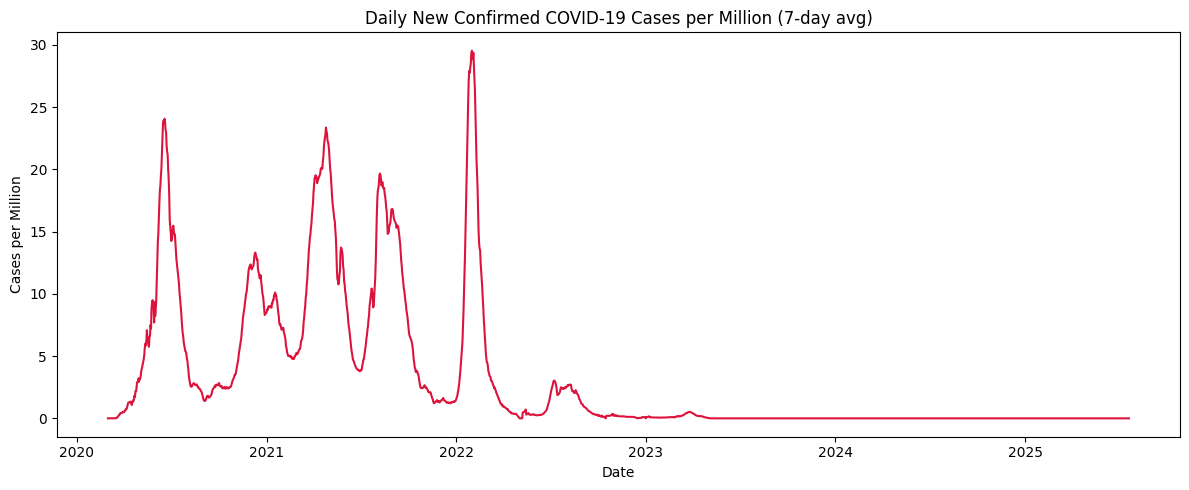

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(covid_df['Day'], covid_df['CasesPerMillion'], color='crimson')
plt.title('Daily New Confirmed COVID-19 Cases per Million (7-day avg)')
plt.xlabel('Date')
plt.ylabel('Cases per Million')
plt.tight_layout()
plt.show()

## Peak Day

In [9]:
peak_row = covid_df.loc[covid_df['CasesPerMillion'].idxmax()]
peak_row

Entity                        Pakistan
Day                2022-01-31 00:00:00
CasesPerMillion               29.53624
Name: 701, dtype: object

## Yearly Summary

In [10]:
yearly_summary = (
    covid_df.groupby(covid_df['Day'].dt.year)['CasesPerMillion']
    .agg(['mean', 'max', 'sum'])
    .rename_axis('Year')
)
yearly_summary

,mean,max,sum
Year,,,
2020,6.319342,24.068172,1933.718660
2021,9.246680,23.364735,3375.038067
2022,3.169206,29.536240,1156.760072
2023,0.055986,0.519959,20.434909
2024,0.000000,0.000000,0.000000
2025,0.000000,0.000000,0.000000


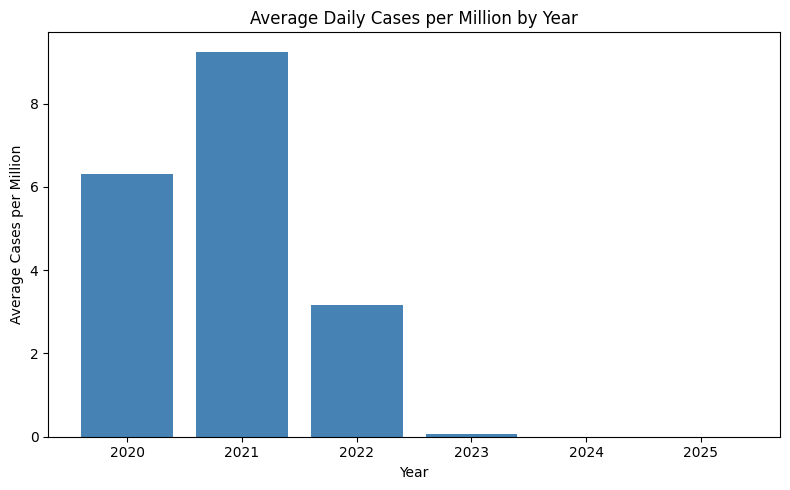

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(yearly_summary.index.astype(str), yearly_summary['mean'], color='steelblue')
plt.title('Average Daily Cases per Million by Year')
plt.xlabel('Year')
plt.ylabel('Average Cases per Million')
plt.tight_layout()
plt.show()

## Monthly Trend

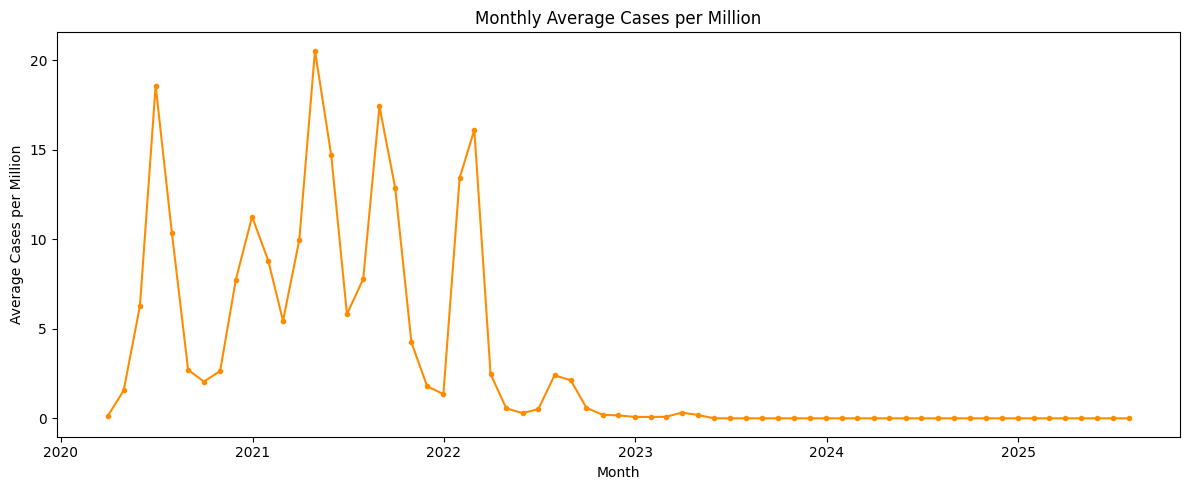

In [12]:
monthly_avg = (
    covid_df.set_index('Day')['CasesPerMillion']
    .resample('ME')
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', markersize=3, color='darkorange')
plt.title('Monthly Average Cases per Million')
plt.xlabel('Month')
plt.ylabel('Average Cases per Million')
plt.tight_layout()
plt.show()

## Distribution of Daily Cases

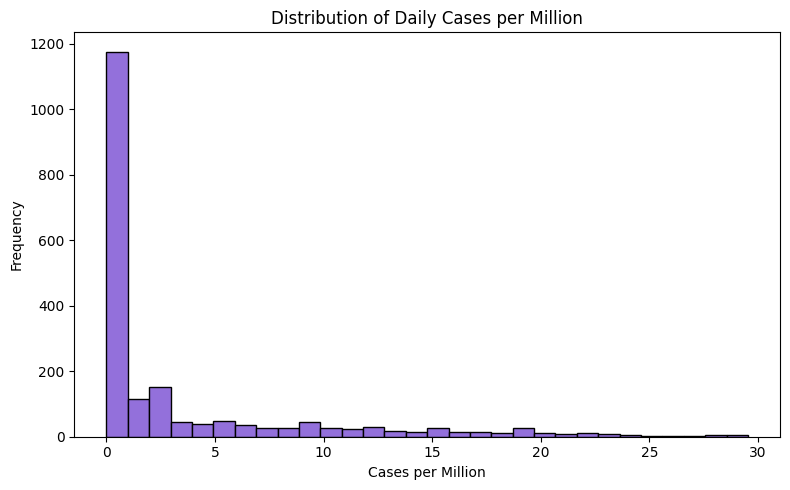

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(covid_df['CasesPerMillion'], bins=30, color='mediumpurple', edgecolor='black')
plt.title('Distribution of Daily Cases per Million')
plt.xlabel('Cases per Million')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()